# Insurance Claims Fraud — Exploratory Analysis

This notebook loads the raw dataset and does a first-pass exploration: shape, data types, nulls, and starter visualizations. The goal is to find one interesting question to drive the focused analysis in notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/fraud_oracle.csv")
print("Shape:", df.shape)

Matplotlib is building the font cache; this may take a moment.


Shape: (15420, 33)


## Data types and first rows

In [2]:
df.dtypes

Month                     str
WeekOfMonth             int64
DayOfWeek                 str
Make                      str
AccidentArea              str
DayOfWeekClaimed          str
MonthClaimed              str
WeekOfMonthClaimed      int64
Sex                       str
MaritalStatus             str
Age                     int64
Fault                     str
PolicyType                str
VehicleCategory           str
VehiclePrice              str
FraudFound_P            int64
PolicyNumber            int64
RepNumber               int64
Deductible              int64
DriverRating            int64
Days_Policy_Accident      str
Days_Policy_Claim         str
PastNumberOfClaims        str
AgeOfVehicle              str
AgeOfPolicyHolder         str
PoliceReportFiled         str
WitnessPresent            str
AgentType                 str
NumberOfSuppliments       str
AddressChange_Claim       str
NumberOfCars              str
Year                    int64
BasePolicy                str
dtype: obj

In [3]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [4]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


## Null counts

In [5]:
df.isnull().sum().sort_values(ascending=False)

Month                   0
RepNumber               0
Year                    0
NumberOfCars            0
AddressChange_Claim     0
NumberOfSuppliments     0
AgentType               0
WitnessPresent          0
PoliceReportFiled       0
AgeOfPolicyHolder       0
AgeOfVehicle            0
PastNumberOfClaims      0
Days_Policy_Claim       0
Days_Policy_Accident    0
DriverRating            0
Deductible              0
PolicyNumber            0
WeekOfMonth             0
FraudFound_P            0
VehiclePrice            0
VehicleCategory         0
PolicyType              0
Fault                   0
Age                     0
MaritalStatus           0
Sex                     0
WeekOfMonthClaimed      0
MonthClaimed            0
DayOfWeekClaimed        0
AccidentArea            0
Make                    0
DayOfWeek               0
BasePolicy              0
dtype: int64

## Starter visualizations

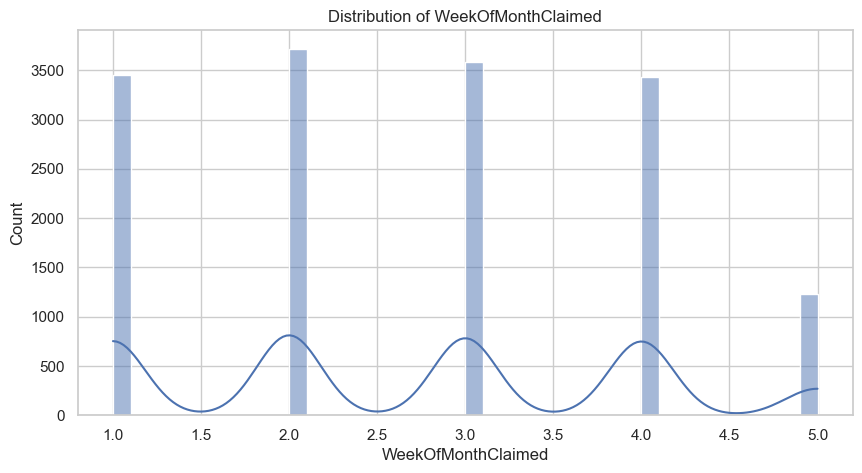

In [6]:
# Distribution of total claim amount
amount_col = [c for c in df.columns if "claim" in c.lower() and df[c].dtype in [float, int]]
if amount_col:
    sns.histplot(df[amount_col[0]].dropna(), bins=40, kde=True)
    plt.title(f"Distribution of {amount_col[0]}")
    plt.xlabel(amount_col[0])
    plt.show()
else:
    print("Columns:", df.columns.tolist())

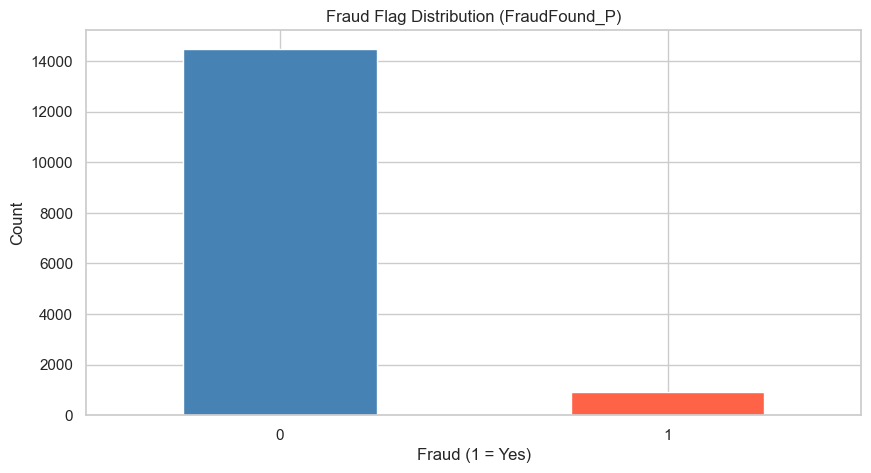

In [7]:
# Fraud vs non-fraud counts
fraud_col = [c for c in df.columns if "fraud" in c.lower()]
if fraud_col:
    df[fraud_col[0]].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
    plt.title(f"Fraud Flag Distribution ({fraud_col[0]})")
    plt.xlabel("Fraud (1 = Yes)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

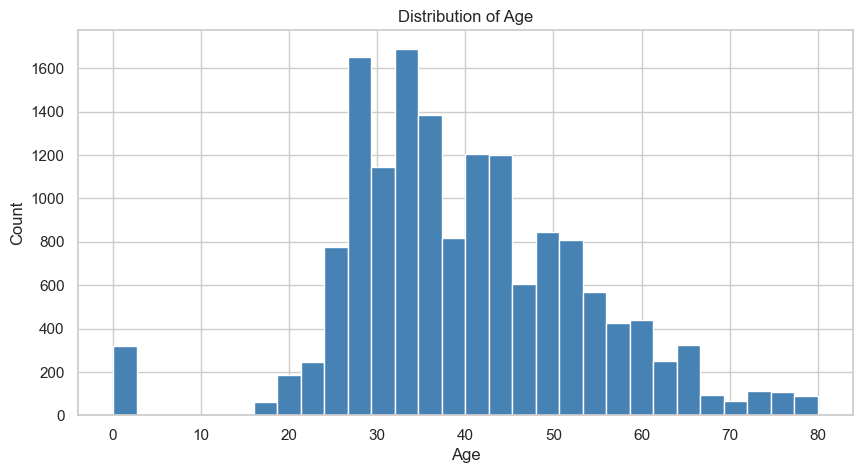

In [8]:
# Claims by age group
age_col = [c for c in df.columns if "age" in c.lower()]
if age_col:
    df[age_col[0]].hist(bins=30, edgecolor="white", color="steelblue")
    plt.title(f"Distribution of {age_col[0]}")
    plt.xlabel(age_col[0])
    plt.ylabel("Count")
    plt.show()

In [9]:
# Top categorical columns — show value counts for first 3 object columns
cat_cols = df.select_dtypes(include="object").columns[:3]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- Month ---
Month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Name: count, dtype: int64

--- DayOfWeek ---
DayOfWeek
Monday       2616
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64

--- Make ---
Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Name: count, dtype: int64


/var/folders/4k/7mnl5n955wq0s8cxjq594mjr0000gn/T/ipykernel_5348/2562641946.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns[:3]
